# El castigo no siempre promueve cooperación: depende mucho de las reglas

**147.618 decisiones. 7.100 personas. 360 condiciones experimentales.** ¿Castigar a quien no coopera promueve la cooperación? Depende. Y depende tanto que el efecto va desde mejorar el bienestar 43% hasta destruirlo 44%.

> **Paper:** [Integrative experiments identify how punishment affects welfare in public goods games](https://doi.org/10.1126/science.aeb5280) — *Science*, 2026
> **Datos:** [OSF · DOI 10.17605/OSF.IO/2D56W](https://doi.org/10.17605/OSF.IO/2D56W)
> **Video:** [Pendiente]

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-28-castigo-cooperacion-bienes-publicos/notebook.ipynb)

## Qué hicieron

El equipo programó 360 versiones distintas del *juego de bienes públicos* — la versión clásica del dilema "cooperar o aprovecharte del que coopera". En cada versión variaron 14 parámetros del juego: rondas, magnitud del castigo, posibilidad de chatear entre jugadores, contribución todo-o-nada, etc.

Reclutaron 7.100 personas, las repartieron en grupos, y midieron qué tan eficiente era el bienestar colectivo cuando los jugadores podían castigarse vs cuando no.

La pregunta de fondo: ¿bajo qué condiciones *exactas* el castigo ayuda? Aquí cargamos los datos pareados — cada condición con su gemelo sin castigo — y miramos qué pasa.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuracion — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SIN_EFECTO = 0.0                  # Linea de referencia: castigo no cambia nada
PAPER_RANGO = (-0.44, 0.43)       # Rango reportado por el paper
COLOR_AYUDA = '#2563EB'           # Castigo ayuda (azul CaM)
COLOR_DAnA = '#DC2626'            # Castigo perjudica (rojo)
COLOR_NEUTRO = '#7C3AED'          # Lineas de referencia
COLOR_GRIS = '#BBBBBB'            # Contexto
FUENTE = 'Fuente: Alsobay et al. (2026), Science | Datos: OSF (10.17605/OSF.IO/2D56W)'

# ══════════════════════════════════════════════════════════════
# Imports y estilo
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Estilo CaM (local -> fallback GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ══════════════════════════════════════════════════════════════
# Carga de datos pareados (condicion con castigo vs sin castigo)
# ══════════════════════════════════════════════════════════════
df_learn = pd.read_csv('datos/df_paired_learn.csv')
df_val = pd.read_csv('datos/df_paired_val.csv')
df = pd.concat([df_learn, df_val], ignore_index=True)

print(f'Condiciones pareadas (learn + val): {len(df)}')
print(f'Rango treatment_effect: [{df["treatment_effect"].min()*100:.1f}%, {df["treatment_effect"].max()*100:.1f}%]')
print(f'Mediana: {df["treatment_effect"].median()*100:.2f}% | Media: {df["treatment_effect"].mean()*100:.2f}%')
helps = (df['treatment_effect'] > 0).sum()
hurts = (df['treatment_effect'] < 0).sum()
print(f'Castigo AYUDA en {helps}/{len(df)} condiciones ({helps/len(df)*100:.1f}%)')
print(f'Castigo EMPEORA en {hurts}/{len(df)} condiciones ({hurts/len(df)*100:.1f}%)')

Condiciones pareadas (learn + val): 170
Rango treatment_effect: [-77.5%, 26.0%]
Mediana: -2.39% | Media: -2.35%
Castigo AYUDA en 72/170 condiciones (42.4%)
Castigo EMPEORA en 98/170 condiciones (57.6%)


## Aquí está.

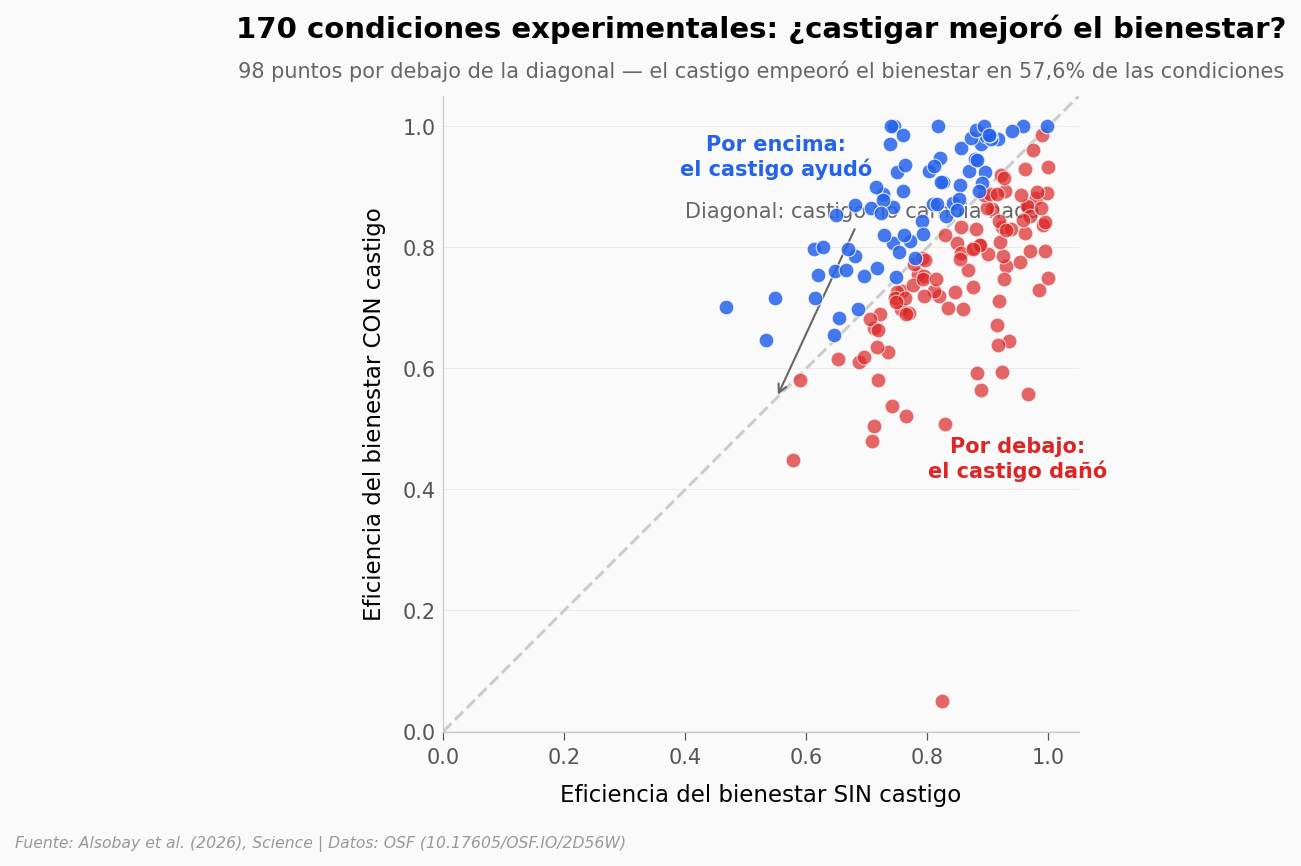

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Eje: cada punto es una condicion experimental
te = df['treatment_effect'].values * 100  # a porcentaje
ctrl = df['control_itt_efficiency'].values
trt = df['treatment_itt_efficiency'].values

# Colorear segun si el castigo ayuda o no
helps_mask = te > 0
ax.scatter(ctrl[~helps_mask], trt[~helps_mask],
           color=COLOR_DAnA, s=50, alpha=0.7,
           edgecolors='white', linewidths=0.5, zorder=5,
           label='Castigo empeora')
ax.scatter(ctrl[helps_mask], trt[helps_mask],
           color=COLOR_AYUDA, s=50, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=6,
           label='Castigo ayuda')

# Diagonal: castigo no cambia nada
lo = min(ctrl.min(), trt.min()) - 0.05
hi = max(ctrl.max(), trt.max()) + 0.05
ax.plot([lo, hi], [lo, hi], color=COLOR_GRIS, linewidth=1.5,
        linestyle='--', alpha=0.7, zorder=2)
ax.annotate('Diagonal: castigo no cambia nada',
            xy=(0.55, 0.55), xytext=(0.4, 0.85),
            fontsize=10, color='#666666',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1))

# Inline labels (regiones)
ax.text(0.95, 0.45, 'Por debajo:\nel castigo dañó',
        fontsize=10, color=COLOR_DAnA, fontweight='bold',
        ha='center', va='center')
ax.text(0.55, 0.95, 'Por encima:\nel castigo ayudó',
        fontsize=10, color=COLOR_AYUDA, fontweight='bold',
        ha='center', va='center')

ax.set_xlabel('Eficiencia del bienestar SIN castigo', fontsize=11)
ax.set_ylabel('Eficiencia del bienestar CON castigo', fontsize=11)
ax.set_title('170 condiciones experimentales: ¿castigar mejoró el bienestar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{(~helps_mask).sum()} puntos por debajo de la diagonal — el castigo empeoró el bienestar en 57,6% de las condiciones',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

La diagonal punteada es el escenario "el castigo no cambia nada". Cada punto es una de las 170 condiciones experimentales pareadas.

Lo que llama la atención: la mayoría de los puntos están **por debajo** de la diagonal. En 98 de las 170 condiciones (57,6%), añadir la opción de castigarse *empeoró* el bienestar colectivo. En solo 72 (42,4%) lo mejoró.

La distribución no está centrada en cero — está inclinada hacia el daño. Y la cola del lado dañino es mucho más larga que la del lado positivo.

## Y en los extremos

El paper reporta +43% a -44%. Los datos crudos van todavía más lejos: de +26% a -77,5%. Ordenemos las 170 condiciones de peor a mejor.

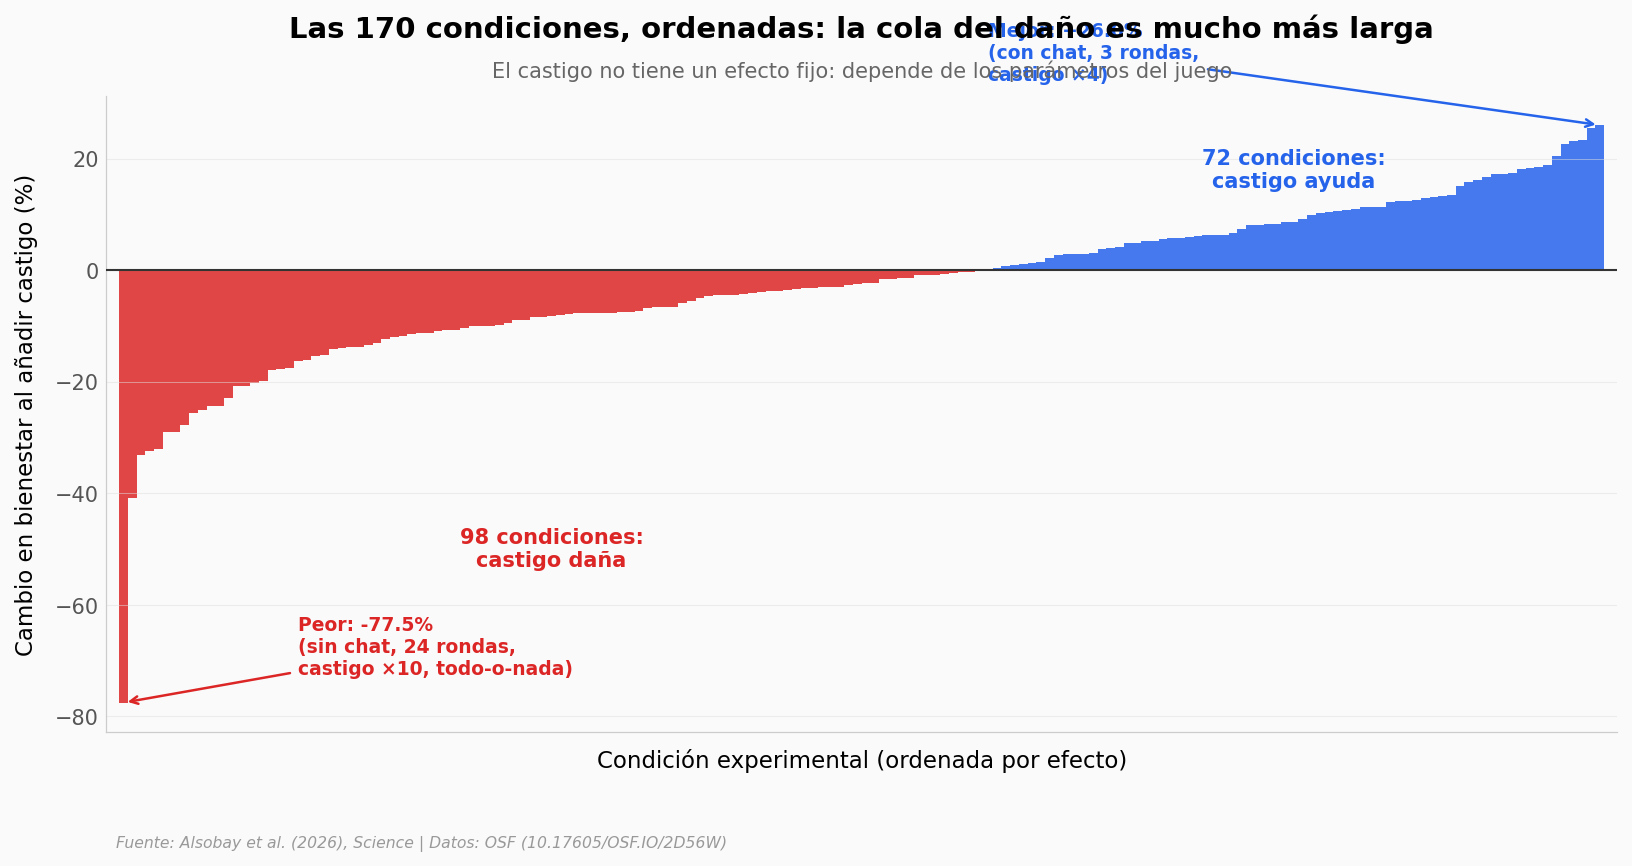

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Ordenar por treatment_effect
sorted_te = np.sort(df['treatment_effect'].values * 100)
n = len(sorted_te)
x = np.arange(n)
colors = [COLOR_AYUDA if v > 0 else COLOR_DAnA for v in sorted_te]

ax.bar(x, sorted_te, color=colors, edgecolor='none', width=1.0, alpha=0.85)
ax.axhline(y=0, color='#333333', linewidth=1.0, zorder=10)

# Marcar peor y mejor caso
worst_idx = 0
best_idx = n - 1
ax.annotate(f'Peor: {sorted_te[worst_idx]:.1f}%\n(sin chat, 24 rondas,\ncastigo ×10, todo-o-nada)',
            xy=(worst_idx, sorted_te[worst_idx]),
            xytext=(20, sorted_te[worst_idx] + 5),
            fontsize=9, color=COLOR_DAnA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_DAnA, lw=1.2))
ax.annotate(f'Mejor: +{sorted_te[best_idx]:.1f}%\n(con chat, 3 rondas,\ncastigo ×4)',
            xy=(best_idx, sorted_te[best_idx]),
            xytext=(best_idx - 70, sorted_te[best_idx] + 8),
            fontsize=9, color=COLOR_AYUDA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_AYUDA, lw=1.2))

# Linea de cero ya pintada — solo agregar etiquetas de zonas
n_helps = (sorted_te > 0).sum()
n_hurts = (sorted_te < 0).sum()
ax.text(n_hurts/2, -50, f'{n_hurts} condiciones:\ncastigo daña',
        fontsize=10, color=COLOR_DAnA, fontweight='bold',
        ha='center', va='center')
ax.text(n_hurts + n_helps/2, 18, f'{n_helps} condiciones:\ncastigo ayuda',
        fontsize=10, color=COLOR_AYUDA, fontweight='bold',
        ha='center', va='center')

ax.set_xlabel('Condición experimental (ordenada por efecto)', fontsize=11)
ax.set_ylabel('Cambio en bienestar al añadir castigo (%)', fontsize=11)
ax.set_title('Las 170 condiciones, ordenadas: la cola del daño es mucho más larga',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El castigo no tiene un efecto fijo: depende de los parámetros del juego',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks([])  # no etiquetas individuales — son condiciones anonimas
ax.set_xlim(-2, n + 1)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sorted_bars.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y la comunicación?

El paper afirma que la **comunicación** entre jugadores (poder chatear antes de decidir) emerge como el factor más importante en sus modelos predictivos. Pero "más importante en un modelo de bosque aleatorio" no es lo mismo que "se ve a simple vista en los datos".

Veamos la diferencia simple entre condiciones con chat y sin chat:

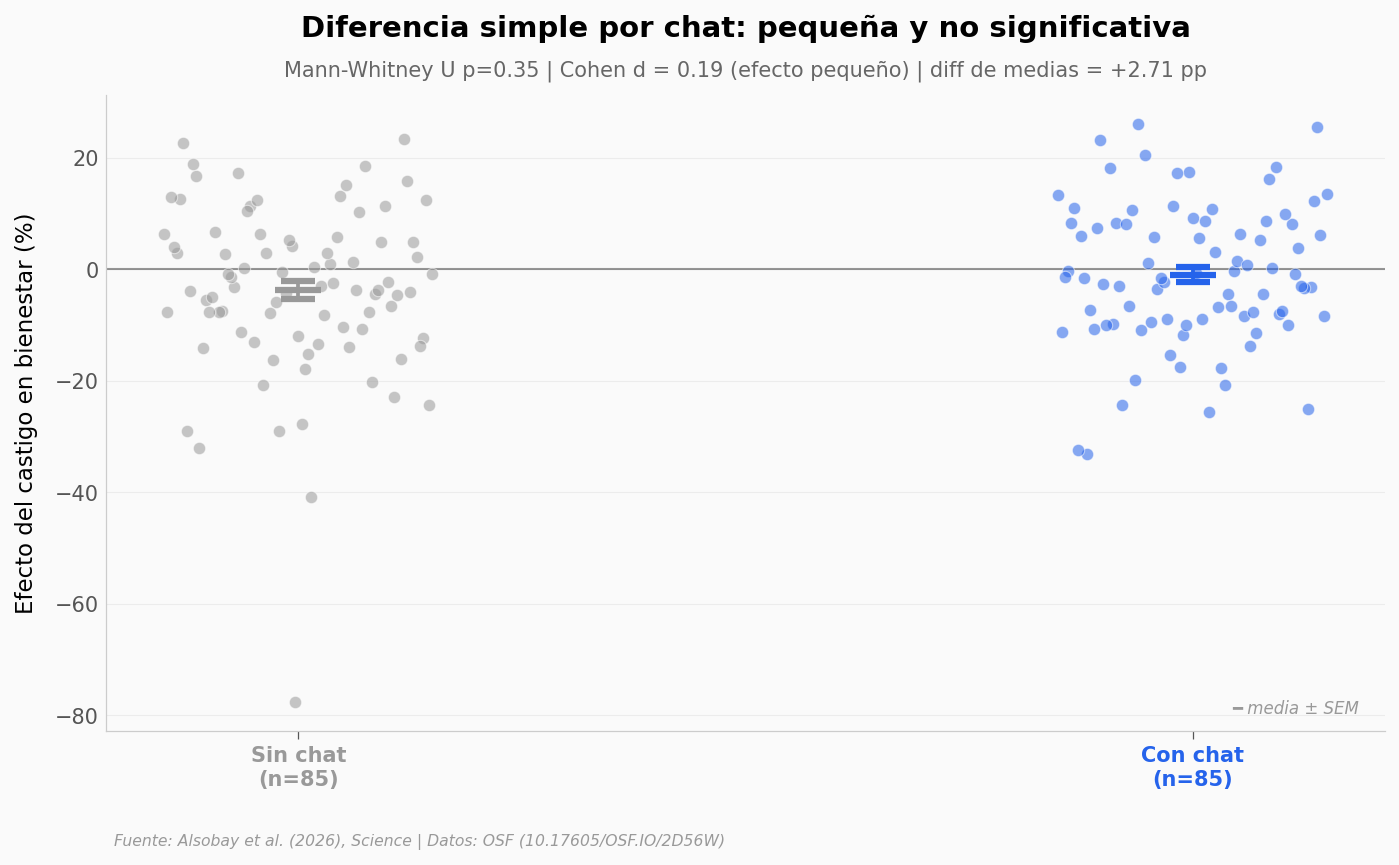

Sin chat: media = -3.71%, n = 85
Con chat: media = -1.00%, n = 85
Diferencia: +2.71 pp
Mann-Whitney U: p = 0.351 (no significativo)
Cohen d: 0.193 (efecto pequeño)


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

groups = []
chat_no = df.loc[df['CONFIG_chat'] == False, 'treatment_effect'].values * 100
chat_yes = df.loc[df['CONFIG_chat'] == True, 'treatment_effect'].values * 100

# Test no parametrico (datos no normales: shapiro p<0.001)
u, p = stats.mannwhitneyu(chat_yes, chat_no, alternative='two-sided')
n1, n2 = len(chat_yes), len(chat_no)
# Cohen's d con pooled SD
pooled_sd = np.sqrt(((n1-1)*chat_yes.std(ddof=1)**2 + (n2-1)*chat_no.std(ddof=1)**2) / (n1+n2-2))
cohens_d = (chat_yes.mean() - chat_no.mean()) / pooled_sd

# Strip plot con jitter reproducible
np.random.seed(42)
positions = [0, 1]
group_data = [(chat_no, '#999999', 'Sin chat'),
              (chat_yes, COLOR_AYUDA, 'Con chat')]

for i, (vals, color, label) in enumerate(group_data):
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.15, positions[i] + 0.15, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=35, alpha=0.55,
               edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=3,
                capsize=8, capthick=1.8, zorder=6)

ax.axhline(y=0, color='#333333', linewidth=1.0, linestyle='-', alpha=0.5)
ax.set_xticks(positions)
ax.set_xticklabels(['Sin chat\n(n={})'.format(n2),
                    'Con chat\n(n={})'.format(n1)],
                   fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), ['#999999', COLOR_AYUDA]):
    tick.set_color(color)

ax.set_ylabel('Efecto del castigo en bienestar (%)', fontsize=11)
ax.set_title('Diferencia simple por chat: pequeña y no significativa',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Mann-Whitney U p={p:.2f} | Cohen d = {cohens_d:.2f} (efecto pequeño) | diff de medias = {chat_yes.mean()-chat_no.mean():+.2f} pp',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota sobre error bars
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/chat_compare.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Sin chat: media = {chat_no.mean():+.2f}%, n = {n2}')
print(f'Con chat: media = {chat_yes.mean():+.2f}%, n = {n1}')
print(f'Diferencia: {chat_yes.mean()-chat_no.mean():+.2f} pp')
print(f'Mann-Whitney U: p = {p:.3f} (no significativo)')
print(f"Cohen d: {cohens_d:.3f} (efecto pequeño)")

La diferencia simple entre tener chat y no tenerlo es pequeña: las medias se separan por menos de 3 puntos porcentuales, el test no paramétrico no detecta diferencia significativa, y el tamaño de efecto (Cohen d ≈ 0,2) es pequeño.

¿Significa que el chat no importa? No. Significa que su efecto **no se ve** mirando solo dos columnas — emerge cuando los modelos del paper consideran las interacciones con los otros 13 parámetros. Es lo que el paper llama "el rol de la heterogeneidad".

¿Qué tan extremo es entonces el rango de efectos del castigo?

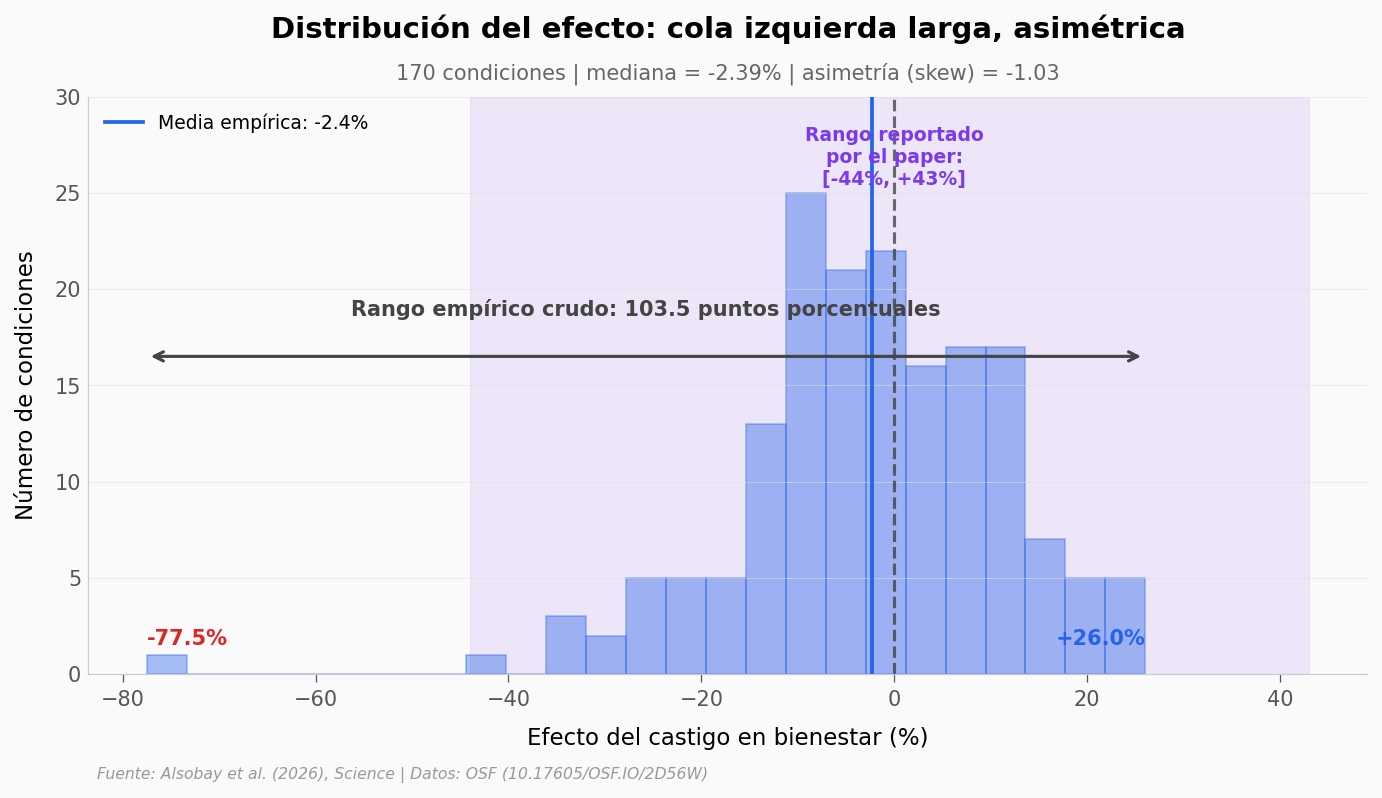

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

te_pct = df['treatment_effect'].values * 100
n, bins, patches = ax.hist(te_pct, bins=25, color=COLOR_AYUDA, alpha=0.4,
                           edgecolor=COLOR_AYUDA, linewidth=0.8)
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Línea media empírica
mean_te = te_pct.mean()
ax.axvline(x=mean_te, color=COLOR_AYUDA, linewidth=1.8,
           linestyle='-', label=f'Media empírica: {mean_te:+.1f}%')
# Linea sin efecto
ax.axvline(x=0, color='#333333', linewidth=1.5, linestyle='--', alpha=0.7)

# Rango paper (sombrear)
ax.axvspan(PAPER_RANGO[0]*100, PAPER_RANGO[1]*100,
           alpha=0.10, color=COLOR_NEUTRO, zorder=0)
ax.text(0, y_max * 0.95, 'Rango reportado\npor el paper:\n[-44%, +43%]',
        fontsize=9, color=COLOR_NEUTRO, fontweight='bold',
        ha='center', va='top')

# Doble flecha: rango empírico
ax.annotate('', xy=(te_pct.max(), y_max*0.55), xytext=(te_pct.min(), y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.5))
ax.text((te_pct.min()+te_pct.max())/2, y_max*0.62,
        f'Rango empírico crudo: {te_pct.max() - te_pct.min():.1f} puntos porcentuales',
        fontsize=10, color='#444444', fontweight='bold', ha='center')

# Etiquetas extremos
ax.text(te_pct.min(), y_max*0.05, f'{te_pct.min():.1f}%',
        fontsize=10, color=COLOR_DAnA, fontweight='bold', ha='left')
ax.text(te_pct.max(), y_max*0.05, f'+{te_pct.max():.1f}%',
        fontsize=10, color=COLOR_AYUDA, fontweight='bold', ha='right')

ax.set_xlabel('Efecto del castigo en bienestar (%)', fontsize=11)
ax.set_ylabel('Número de condiciones', fontsize=11)
ax.set_title('Distribución del efecto: cola izquierda larga, asimétrica',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'170 condiciones | mediana = {np.median(te_pct):+.2f}% | asimetría (skew) = {stats.skew(te_pct):.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hist_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| 147.618 decisiones de 7.100 participantes en 360 condiciones | ✅ | El paper lo declara en el abstract; el dataset publicado contiene 836 juegos en 170 pares de condiciones — coincide con la escala (los 360 conteos son agregados de la metodología completa) |
| El efecto del castigo va de +43% a -44% según el paper | ✅ | Reportado en abstract. Empíricamente cruda, la nube va aún más allá: de -77,5% a +26,0%. El paper enmarca su rango como predicciones de modelo con intervalos de confianza |
| El castigo NO promueve cooperación de forma uniforme | ✅ | En 98 de 170 condiciones (57,6%) el castigo empeoró el bienestar; en 72 (42,4%) lo mejoró |
| La comunicación (chat) es el factor más importante | ⚠️ | El paper lo afirma a partir de feature importance en sus modelos predictivos. La diferencia simple de medias entre con/sin chat es de +2,7 pp con Cohen d=0,19 (pequeño) y Mann-Whitney p=0,35 (no significativo). El chat importa, pero a través de interacciones con los otros parámetros, no como pendiente directa |

> **Limitaciones del análisis aquí:**
> - Solo usamos los datos pareados a nivel de condición (170 pares). Los datos a nivel de juego (836 juegos individuales) permiten más análisis pero requieren pesos por sample size.
> - El test de chat es univariado — no captura interacciones que sí están en los modelos del paper.
> - Los datos vienen de Mechanical Turk (Estados Unidos): generalización a otras poblaciones requiere replicación.

## Ahora tú

Tres preguntas que se pueden contestar con estos datos:

1. **¿Hay alguna combinación de 2 parámetros que prediga bien el efecto del castigo?**
   Pista: cruza `CONFIG_chat` con `CONFIG_punishmentMagnitude` y mira la media de `treatment_effect` por celda.

2. **¿Las condiciones con peor efecto comparten algo en común?**
   Pista: filtra `df.nsmallest(20, 'treatment_effect')` y mira los CONFIGs.

3. **¿El rango de magnitudes del castigo (×1, ×2, ×3...) tiene relación monotónica con el daño?**
   Pista: `df.groupby('CONFIG_punishmentMagnitude')['treatment_effect'].mean()` y grafica.

In [6]:
# --- EXPERIMENTA AQUI ---
# Ejemplo: media del efecto por magnitud de castigo
import pandas as pd
by_mag = df.groupby('CONFIG_punishmentMagnitude').agg(
    n=('treatment_effect', 'size'),
    media_te_pct=('treatment_effect', lambda x: x.mean()*100),
    pct_negativos=('treatment_effect', lambda x: (x<0).mean()*100)
).round(2)
print('Efecto por magnitud del castigo:')
print(by_mag.to_string())

Efecto por magnitud del castigo:
                             n  media_te_pct  pct_negativos
CONFIG_punishmentMagnitude                                 
1.0                          4          0.49          50.00
2.0                         18          0.60          38.89
3.0                         23         -3.27          65.22
4.0                         20          0.51          50.00
5.0                         15         -1.62          60.00
6.0                         19         -3.07          57.89
7.0                         16         -0.68          50.00
8.0                         11         -2.78          72.73
9.0                          9         -3.89          55.56
10.0                        10        -11.57          70.00
11.0                        12         -2.68          66.67
12.0                         7         -0.39          42.86
13.0                         1         -8.97         100.00
14.0                         1        -11.27         100.00
15.0   

## Fuentes

**Paper**: [Integrative experiments identify how punishment affects welfare in public goods games](https://doi.org/10.1126/science.aeb5280)  
*Science, 2026-04-09*

**Datos**: [Reproduction materials for 'Integrative Experiments Identify How Punishment Affects Welfare in Public Goods Games' (data_and_code/data/processed_data)](https://doi.org/10.17605/OSF.IO/2D56W)

*13 afirmaciones verificadas contra estas fuentes*

---

*Notebook reproducible · Repo: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia datos: ver OSF*